(50, 1)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Text(0.5, 1.0, '$R^2$:0.07')

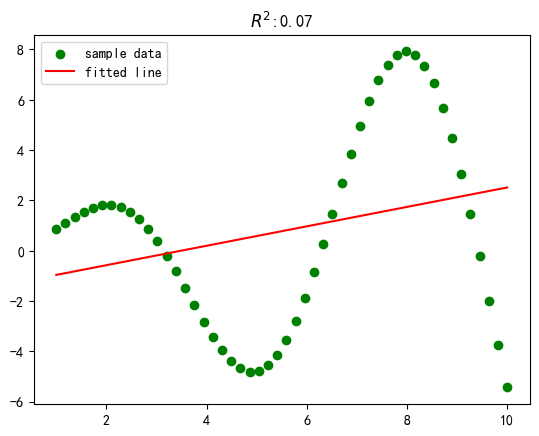

In [ ]:
import numpy as np
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
x=np.linspace(1,10,50)
X=x[:,np.newaxis]
print(X.shape)
y=x*np.sin(x)#under fitting
lr=LinearRegression()
lr.fit(X,y)
plt.scatter(X,y,c='g',label='sample data')
plt.plot(X,lr.predict(X),'r-',label='fitted line')
plt.legend()
plt.title(f'$R^2$:{lr.score(X,y):.2f}')

In [ ]:
#多项式扩展
from sklearn.preprocessing import PolynomialFeatures
X=np.array([[1,2],[3,4]])
poly=PolynomialFeatures(degree=2)
poly.fit(X)
poly.powers_
X_trans=poly.transform(X)
X_trans

,degree,2
,interaction_only,False
,include_bias,True
,order,'C'


array([[0, 0],
       [1, 0],
       [0, 1],
       [2, 0],
       [1, 1],
       [0, 2]], dtype=int64)

array([[ 1.,  1.,  2.,  1.,  2.,  4.],
       [ 1.,  3.,  4.,  9., 12., 16.]])

In [19]:
from sklearn.preprocessing import PolynomialFeatures

X = np.array([[1, 2], [3, 4]])
print(X)
# degree：扩展阶数。
# include_bias：是否包含偏置项（指数值都为0的项），默认值为True。
poly = PolynomialFeatures(degree=2, include_bias=False)
# 拟合数据，根据训练集X与扩展阶数（degree），就可以确定powers_属性。
poly.fit(X)
print(poly.powers_)
# 将参数X进行多项式转换，返回转换结果。
X_trans = poly.transform(X)
print(X_trans)

# 数据预处理类（例如PolynomialFeatures）的实现：
# fit方法通过训练集用来学习转换规则，转换规则通过属性来进行体现，即将转换规则保存在当前对象的某个属性中。
# 例如例如PolynomialFeatures，转换规则保存在powers_属性中。
# transform方法，通过fit方法学习到的转换规则（属性），就可以对任意的数据进行转换。

X2 = np.array([[10, 2], [2, 9,], [-3, 6]])
print(poly.transform(X2))

# 数据预处理类还具有一个fit_transform的方法。相当于同时调用fit与transform。
# 即：
# poly.fit(X)
# X_trans = poly.transform(X)
# 相当于执行：
# X_trans = poly.fit_transform(X)

# 输入特征的数量，与powers_属性的列数一致。
print(poly.n_features_in_)
# 输出特征的数量，与powers_属性的函数一致。
print(poly.n_output_features_)

# 自行计算转换结果。
for x1, x2 in X:
    for e1, e2 in poly.powers_:
        print(x1 ** e1 * x2 ** e2, end="\t")
    print()

[[1 2]
 [3 4]]


,degree,2
,interaction_only,False
,include_bias,False
,order,'C'


[[1 0]
 [0 1]
 [2 0]
 [1 1]
 [0 2]]
[[ 1.  2.  1.  2.  4.]
 [ 3.  4.  9. 12. 16.]]
[[ 10.   2. 100.  20.   4.]
 [  2.   9.   4.  18.  81.]
 [ -3.   6.   9. -18.  36.]]
2
5
1	2	1	2	4	
3	4	9	12	16	
